# Discrete Ricci Flow — Examples

This notebook demonstrates the `ricci` package for designing surfaces with prescribed Gaussian curvature.

**Pipeline overview:**
1. **Load mesh** — `TriangleMesh.from_ply()` or `.from_obj()`
2. **Ricci flow** — `ricci_flow()` finds edge lengths achieving target curvatures
3. **Embed** — `embed()` finds 3D vertex positions realising those edge lengths
4. **Visualise** — `plot_mesh()`, `plot_curvature()`

Reference: S. Kaji and J. Zhang, *Free-form Design of Discrete Architectural Surfaces by use of Circle Packing*, [arXiv:2103.07584](https://arxiv.org/abs/2103.07584)

In [1]:
%matplotlib inline
from ricci import (
    TriangleMesh, DiscreteMetric,
    ricci_flow, embed, curvature_flow,
    plot_mesh, plot_curvature, plot_convergence, plot_comparison,
)

## 1. Load a mesh and inspect it

TriangleMesh(V=26, E=65, F=40, boundary_V=10, chi=1)
Total curvature: 2.00 pi
Valid metric: True


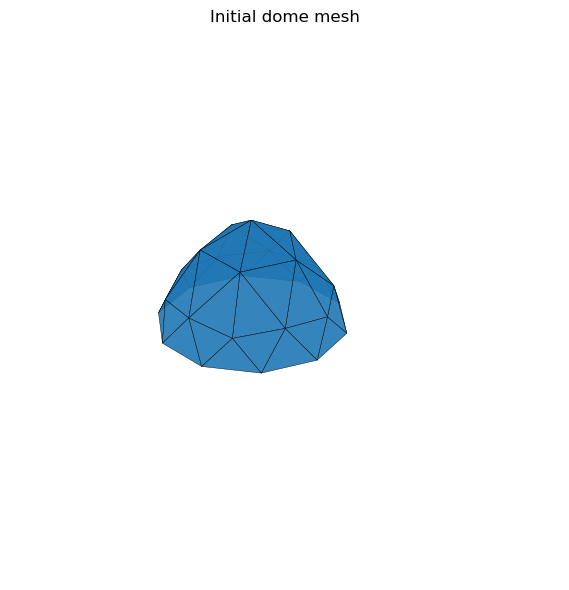

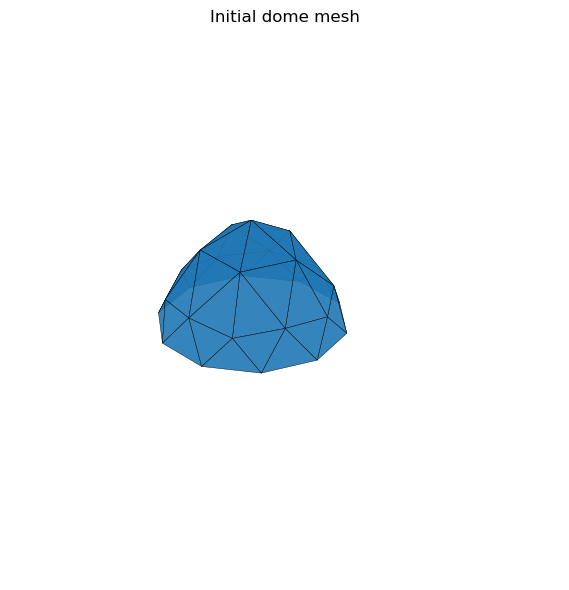

In [13]:
mesh = TriangleMesh.from_ply('demo/dome.ply')
print(mesh)

g = DiscreteMetric(mesh, mesh.edge_lengths)
print(f"Total curvature: {g.total_curvature / 3.14159:.2f} pi")
print(f"Valid metric: {g.is_valid}")

plot_mesh(mesh, show=True, title='Initial dome mesh')

## 2. Ricci flow with fixed boundary

Fix the boundary vertices in place and prescribe uniform Gaussian curvature K=0.1 for interior vertices. The combinatorial scheme ignores initial face shapes and seeks equilateral triangles.

In [14]:
result = ricci_flow(
    mesh,
    target_curvature=0.1,
    fix_boundary=True,
    scheme='combinatorial',
    method='trf',
    gtol=1e-6,
)

import numpy as np
print(f"\nScale factor: {result.scale_factor:.4f}")
print(f"Curvature MAE: {np.abs(result.curvature - result.target_curvature).mean():.2e}")

V=26, E=65, F=40, boundary_V=10, chi=1
specified_verts=16, free_verts=16
target total_K = 2.0000 pi
scale_factor = 1.000000
`gtol` termination condition is satisfied.
Function evaluations 8, initial cost 3.7888e+00, final cost 1.0979e-16, first-order optimality 3.87e-09.
curvature MAE = 6.954317e-10

Scale factor: 1.0000
Curvature MAE: 1.45e-05


## 3. Embed the metric into R^3

Given the optimised edge lengths from Ricci flow, find vertex positions in 3D. Uses PyTorch L-BFGS with autograd.

Embedding: 26 vertices, 65 edges, fixed=0, device=cpu
  Converged at iteration 7
  cost=2.10279043e-10, beta=1.000000, iters=8

Cost: 2.10e-10
Scale factor (beta): 1.000000


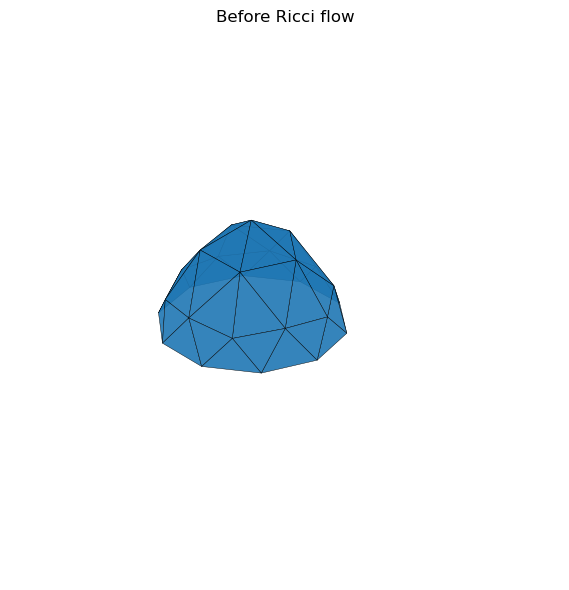

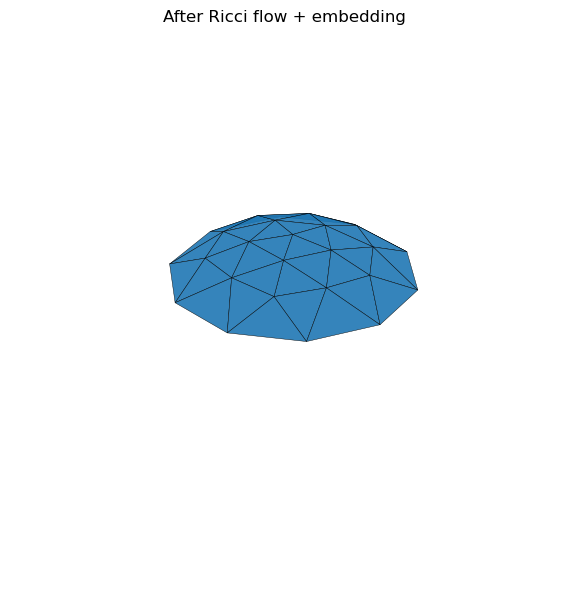

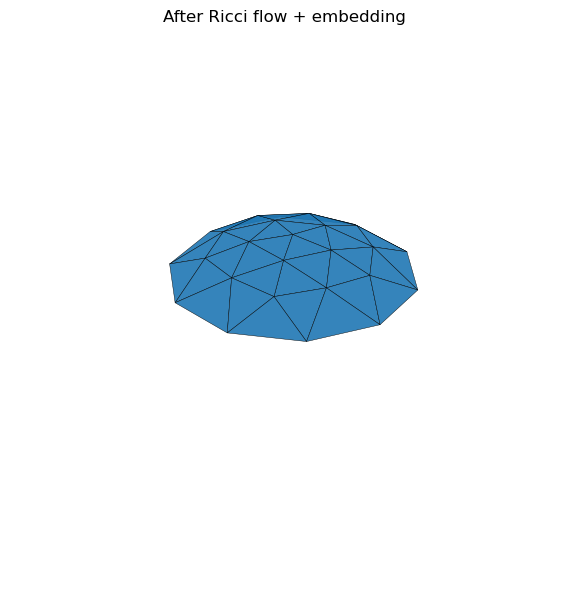

In [4]:
embedded = embed(mesh, result.edge_lengths, gtol=1e-6)

print(f"\nCost: {embedded.cost:.2e}")
print(f"Scale factor (beta): {embedded.scale_factor:.6f}")

# Compare initial and deformed mesh
plot_mesh(mesh, show=True, title='Before Ricci flow')
plot_mesh(embedded.mesh, show=True, title='After Ricci flow + embedding')

## 4. Curvature visualisation

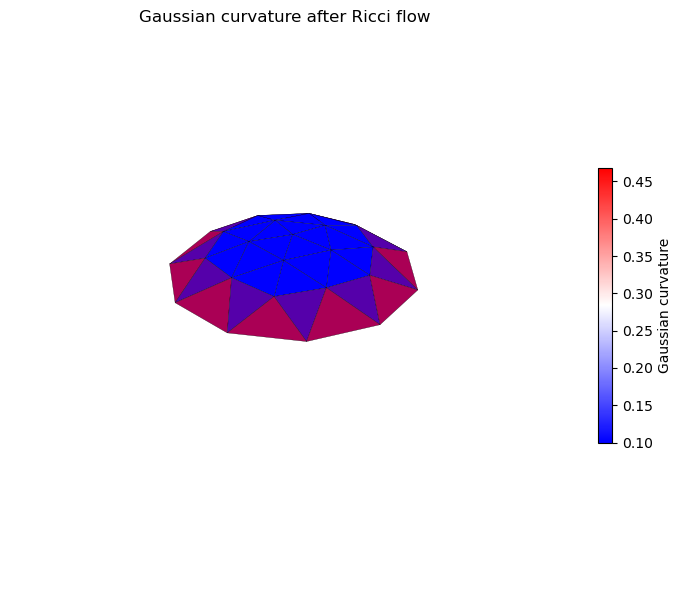

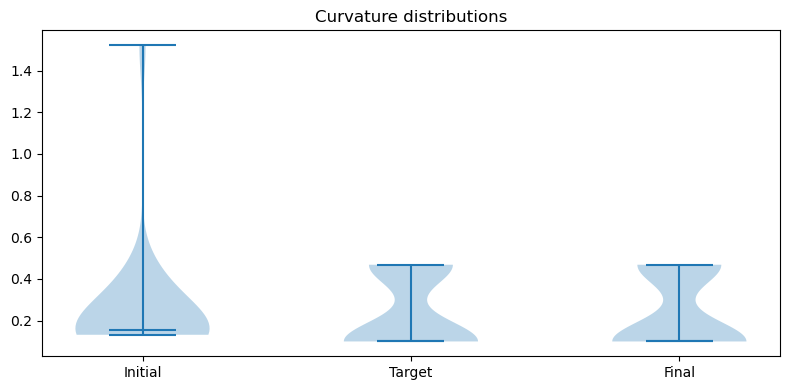

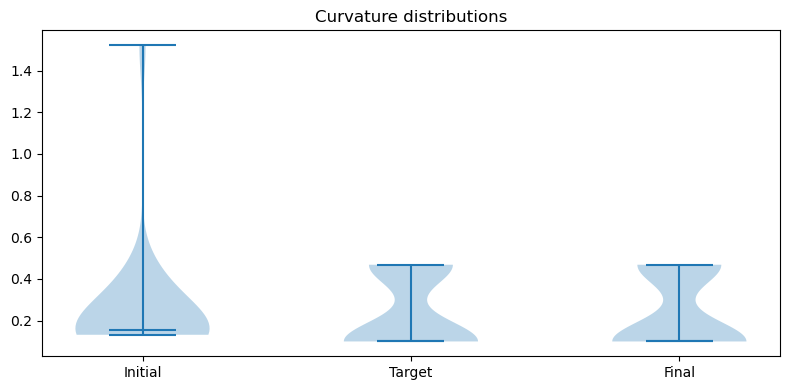

In [5]:
# Curvature of the deformed mesh
g_final = DiscreteMetric(embedded.mesh, embedded.mesh.edge_lengths)
plot_curvature(embedded.mesh, g_final.gaussian_curvature, show=True,
               title='Gaussian curvature after Ricci flow')

# Compare curvature distributions
g_init = DiscreteMetric(mesh, mesh.edge_lengths)
plot_comparison(
    [g_init.gaussian_curvature, result.target_curvature, g_final.gaussian_curvature],
    labels=['Initial', 'Target', 'Final'],
    show=True, title='Curvature distributions',
)

## 5. Free boundary with per-vertex target curvature from CSV

Load per-vertex target curvatures from a CSV file. Vertices not listed (or with K > 2pi) are filled uniformly via the Gauss-Bonnet theorem.

V=26, E=65, F=40, boundary_V=10, chi=1
specified_verts=26, free_verts=26
target total_K = 2.0000 pi
scale_factor = 1.000000
`gtol` termination condition is satisfied.
Function evaluations 8, initial cost 7.1272e+00, final cost 3.6040e-12, first-order optimality 1.29e-10.
curvature MAE = 1.739273e-08
Embedding: 26 vertices, 65 edges, fixed=0, device=cpu
  Converged at iteration 13
  cost=5.13124979e-10, beta=1.000000, iters=14


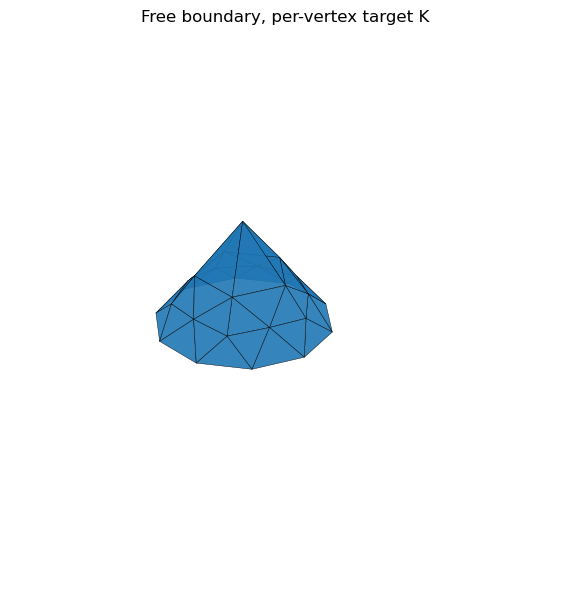

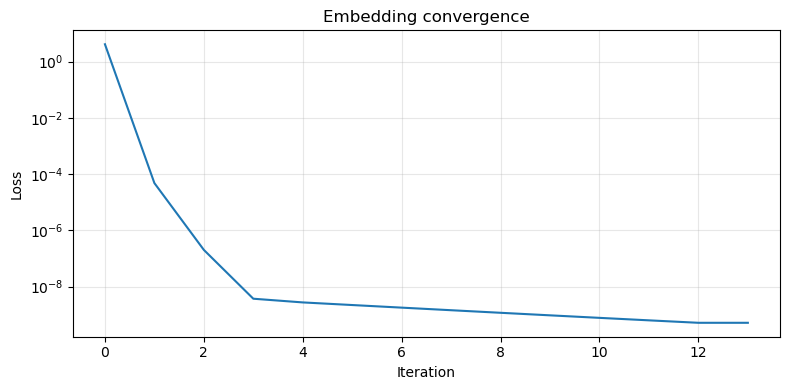

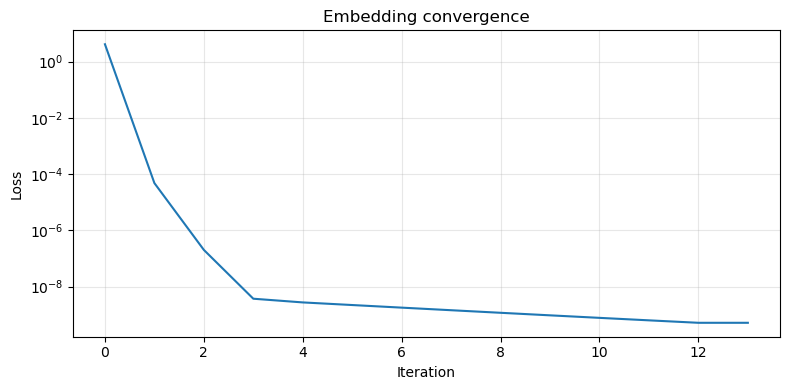

In [6]:
result_csv = ricci_flow(mesh, 'demo/dome_targetK_hat.csv', method='trf', gtol=1e-6)
embedded_csv = embed(mesh, result_csv.edge_lengths, lambda_boundary=0, gtol=1e-6)

plot_mesh(embedded_csv.mesh, show=True, title='Free boundary, per-vertex target K')
plot_convergence(embedded_csv.history, show=True, title='Embedding convergence')

TriangleMesh(V=96, E=245, F=150, boundary_V=40, chi=1)
Total curvature: 2.00 pi
Valid metric: True


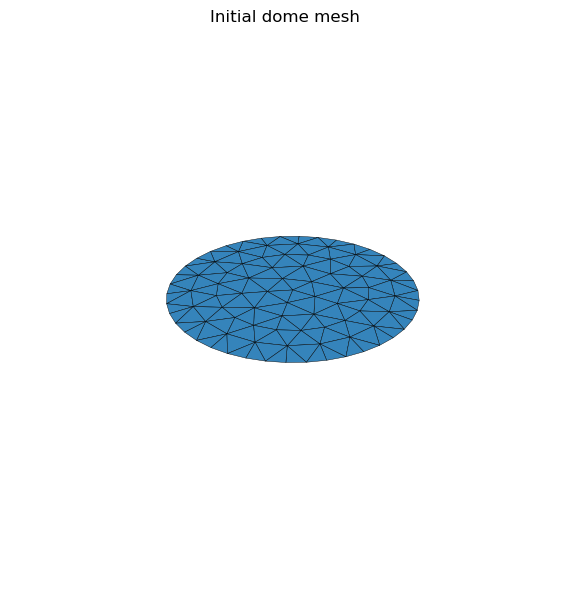

V=96, E=245, F=150, boundary_V=40, chi=1
specified_verts=96, free_verts=96
target total_K = 2.0000 pi
scale_factor = 1.000000
`gtol` termination condition is satisfied.
Function evaluations 10, initial cost 3.6118e+01, final cost 1.0201e-08, first-order optimality 9.65e-08.
curvature MAE = 9.327895e-08
Embedding: 96 vertices, 245 edges, fixed=0, device=cpu
  cost=1.25637738e-02, beta=1.000000, iters=2000


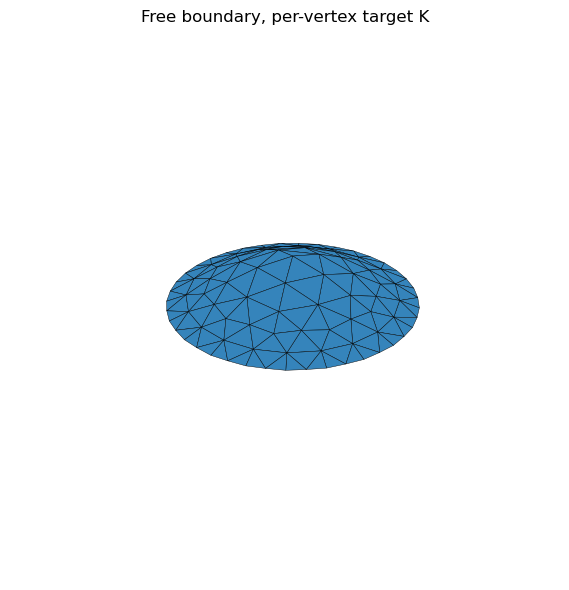

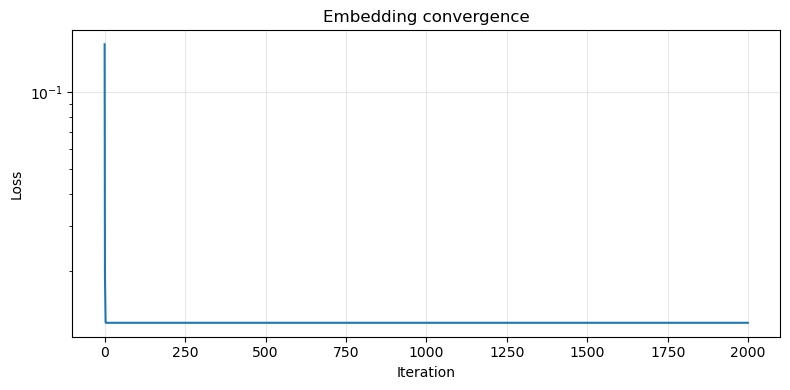

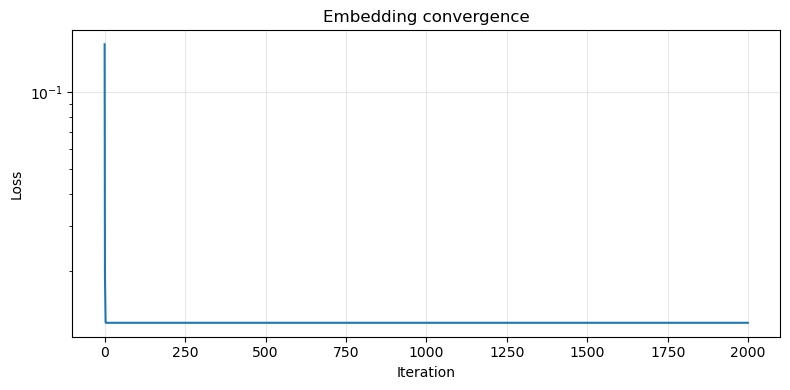

In [20]:
mesh = TriangleMesh.from_ply('demo/dome5.ply')
print(mesh)

g = DiscreteMetric(mesh, mesh.edge_lengths)
print(f"Total curvature: {g.total_curvature / 3.14159:.2f} pi")
print(f"Valid metric: {g.is_valid}")

plot_mesh(mesh, show=True, title='Initial dome mesh')

result_csv = ricci_flow(mesh, 'demo/dome5_targetCurvature.csv', method='trf', gtol=1e-6)
embedded_csv = embed(mesh, result_csv.edge_lengths, lambda_boundary=0, gtol=1e-6, lambda_convexity=.5)

plot_mesh(embedded_csv.mesh, show=True, title='Free boundary, per-vertex target K')
plot_convergence(embedded_csv.history, show=True, title='Embedding convergence')

## 6. Closed surface (torus)

For a closed surface with no boundary, the target curvature must satisfy the Gauss-Bonnet theorem (total K = 2*pi*chi). For a torus, chi=0 so the only admissible uniform curvature is K=0 (flat). Note that no flat torus embeds isometrically in R^3.

TriangleMesh(V=144, E=432, F=288, boundary_V=0, chi=0)
V=144, E=432, F=288, boundary_V=0, chi=0
specified_verts=144, free_verts=144
target total_K = 0.0000 pi
scale_factor = 0.075929
  iter 0: |DeltaK|_1 = 2.229043e+01
  iter 100: |DeltaK|_1 = 5.927137e-04
  Converged in 118 iterations, |DeltaK|_1 = 9.884801e-05
curvature MAE = 6.864445e-07
Embedding: 144 vertices, 432 edges, fixed=0, device=cpu
  Converged at iteration 120
  cost=2.87676901e-04, beta=1.000000, iters=121


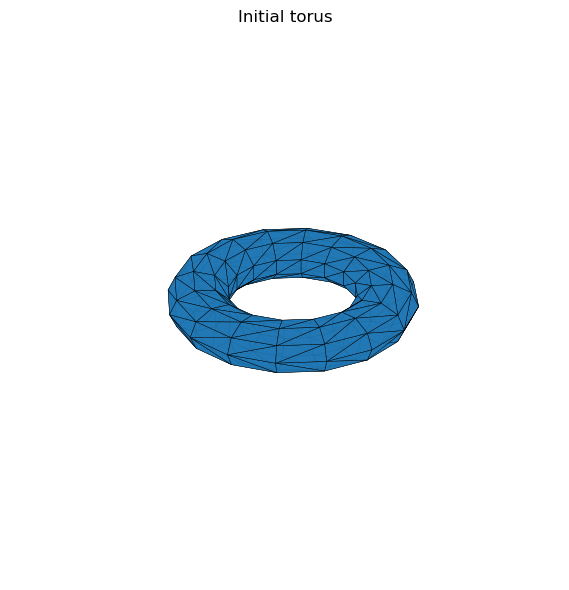

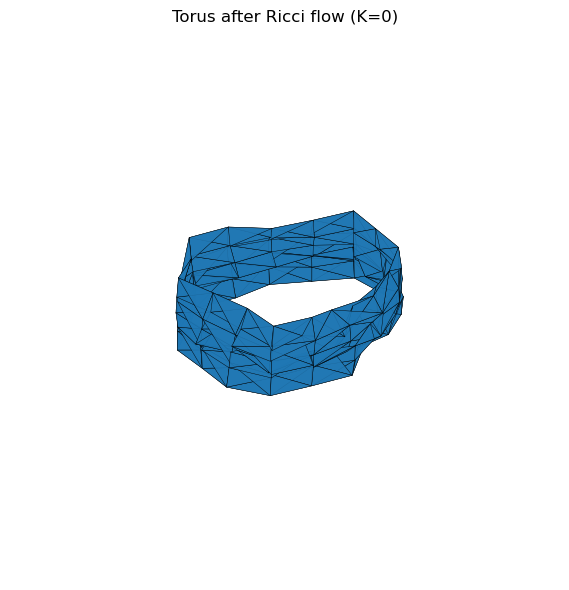


Embed cost: 2.88e-04


In [7]:
torus = TriangleMesh.from_obj('demo/torus.obj')
print(torus)

result_torus = ricci_flow(torus, method='newton', scheme='inversive', lr=0.1, gtol=1e-4)
embedded_torus = embed(torus, result_torus.edge_lengths, lambda_boundary=0, gtol=1e-6)

plot_mesh(torus, show=True, title='Initial torus')
plot_mesh(embedded_torus.mesh, show=True, title='Torus after Ricci flow (K=0)')
print(f"\nEmbed cost: {embedded_torus.cost:.2e}")

## 7. Convexity-enforced embedding

Use `lambda_convexity` to encourage the z-coordinate at each interior vertex to exceed the average of its neighbours (dome shape).

V=26, E=65, F=40, boundary_V=10, chi=1
specified_verts=16, free_verts=16
target total_K = 2.0000 pi
scale_factor = 1.000000
`gtol` termination condition is satisfied.
Function evaluations 8, initial cost 3.7888e+00, final cost 1.0979e-16, first-order optimality 3.87e-09.
curvature MAE = 6.954317e-10
Embedding: 26 vertices, 65 edges, fixed=0, device=cpu
  iter     0  loss=5.59261061e+00  beta=1.000000
  iter    50  loss=2.12269617e-02  beta=1.000000
  iter   100  loss=2.12269617e-02  beta=1.000000
  iter   150  loss=2.12269617e-02  beta=1.000000
  iter   200  loss=2.12269617e-02  beta=1.000000
  iter   250  loss=2.12269617e-02  beta=1.000000
  iter   300  loss=2.12269617e-02  beta=1.000000
  iter   350  loss=2.12269617e-02  beta=1.000000
  iter   400  loss=2.12269617e-02  beta=1.000000
  iter   450  loss=2.12269617e-02  beta=1.000000
  iter   500  loss=2.12269617e-02  beta=1.000000
  iter   550  loss=2.12269617e-02  beta=1.000000
  iter   600  loss=2.12269617e-02  beta=1.000000
  iter  

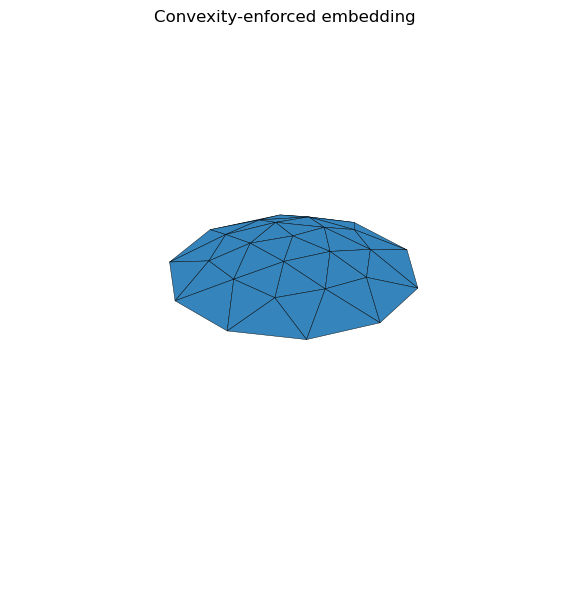

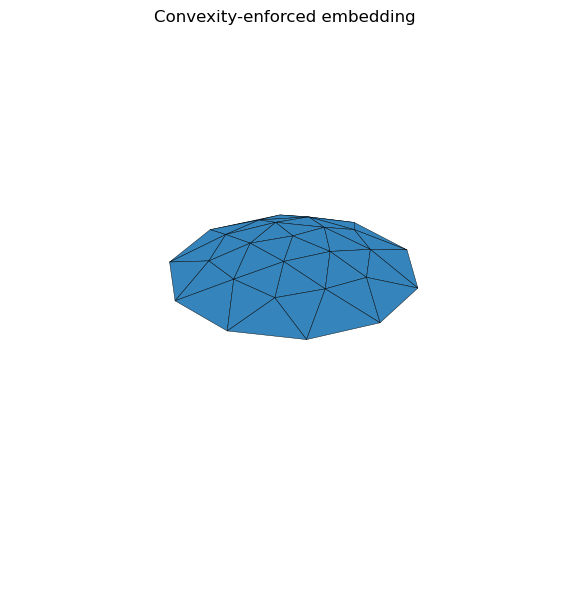

In [8]:
result_convex = ricci_flow(mesh, 0.1, fix_boundary=True, scheme='combinatorial', gtol=1e-6)
embedded_convex = embed(
    mesh, result_convex.edge_lengths,
    lambda_convexity=1.0,
    gtol=1e-6,
    verbose=2,
)

plot_mesh(embedded_convex.mesh, show=True, title='Convexity-enforced embedding')

## 8. Different circle packing schemes

The `scheme` parameter controls the conformal class. Compare **combinatorial** (equilateral-seeking), **inversive** (geometry-preserving), and a **constant eta** value.

scheme=combinatorial    scale=1.0000  embed_cost=1.75e-08


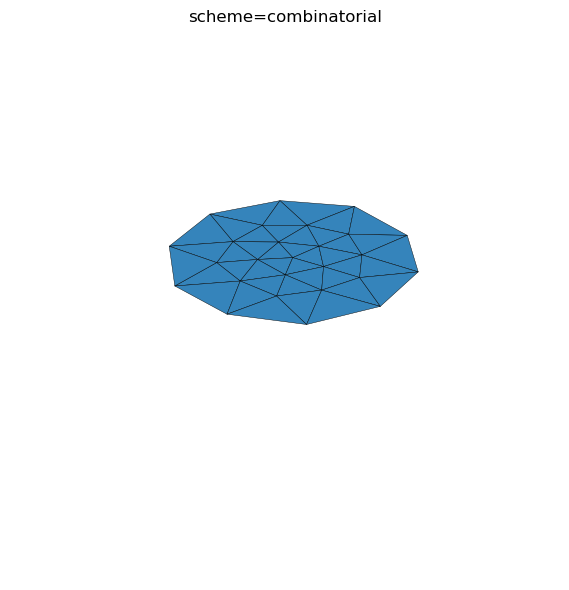

scheme=inversive        scale=0.2905  embed_cost=5.95e-08


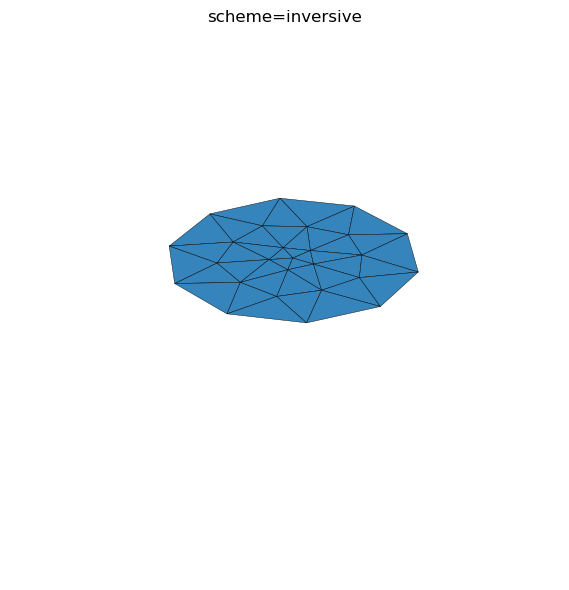

scheme=0.5              scale=1.0000  embed_cost=2.15e-08


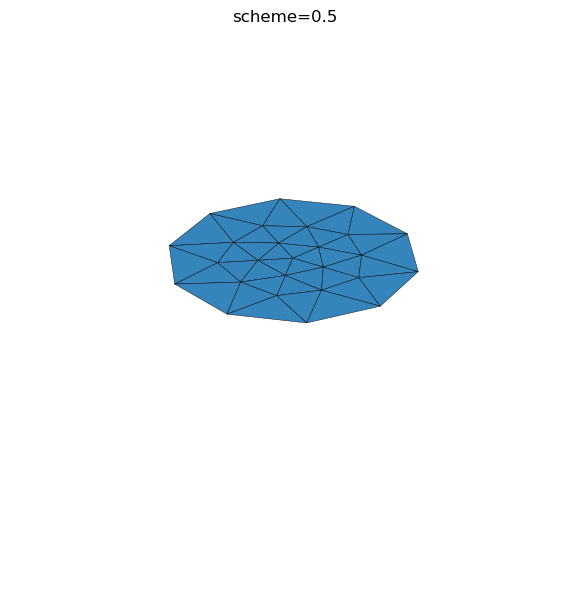

In [9]:
for scheme in ['combinatorial', 'inversive', '0.5']:
    r = ricci_flow(mesh, 0.0, fix_boundary=True, scheme=scheme, gtol=1e-4, verbose=0)
    e = embed(mesh, r.edge_lengths, gtol=1e-5, verbose=0)
    print(f"scheme={scheme:15s}  scale={r.scale_factor:.4f}  embed_cost={e.cost:.2e}")
    plot_mesh(e.mesh, show=True, title=f'scheme={scheme}')

## 9. Direct curvature flow (alternative to Ricci)

Instead of the two-stage pipeline, directly optimise vertex positions to achieve target curvatures. Simpler but slower to converge.

  Uniform target K = 0.468319 at 10 vertices
  V=26, F=40, fixed=10
  Final curvature MAE = 1.208305e+00, iters = 500


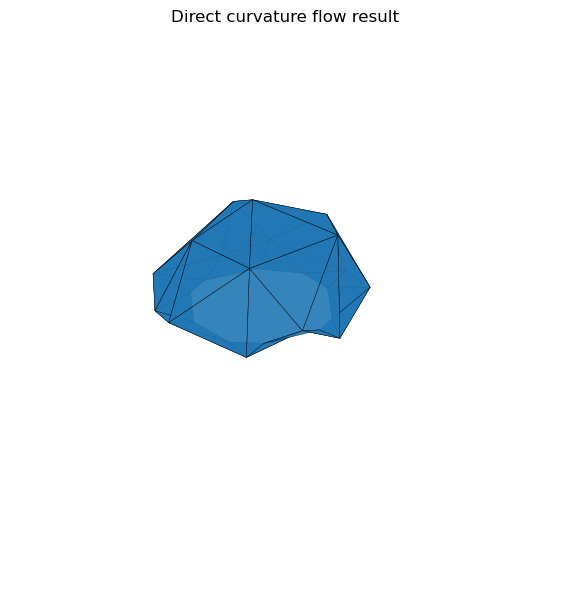

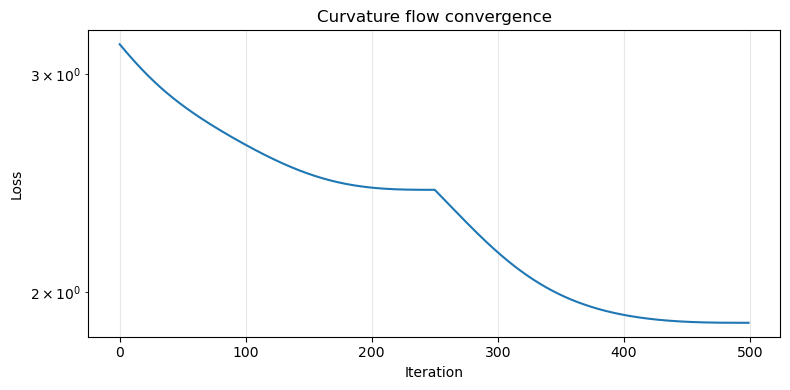

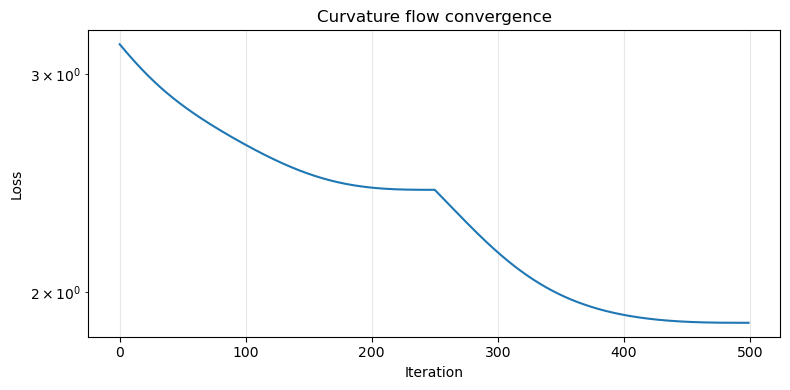

In [10]:
cf_result = curvature_flow(
    mesh, target_curvature=0.1,
    optimizer='Adam', lr=1e-3, max_iter=500,
    verbose=1,
)

plot_mesh(cf_result.mesh, show=True, title='Direct curvature flow result')
plot_convergence(cf_result.history, show=True, title='Curvature flow convergence')

## 10. Save results

Export the deformed mesh as a PLY file.

In [ ]:
import os
os.makedirs('result', exist_ok=True)
embedded.mesh.save_ply('result/dome_deformed.ply')
print("Saved to result/dome_deformed.ply")